# **PRÁCTICA 2**

##### **Iván Ciller López, 100522245**
##### **Mohamed Rida Chahdaoui Moujib, 100522202**

## **APARTADO 1: CODIFICACIÓN DE VARIABLES**

Para comenzar con la práctica, empezamos viendo los distintos valores posibles para **Color** y **Spectral_Class**:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN

# Fijamos la semilla
np.random.seed(100522245)  # Semilla con NIA

# Cargamos los datos
df = pd.read_csv('stars_data.csv')

# Ver valores únicos y cuántos hay de cada uno en la Clase Espectral
print("--- Recuento de Clase Espectral ---")
print(df['Spectral_Class'].value_counts())

print("\n--- Recuento de Colores ---")
# Ver valores únicos de Color
print(df['Color'].value_counts())

--- Recuento de Clase Espectral ---
Spectral_Class
M    111
B     46
O     40
A     19
F     17
K      6
G      1
Name: count, dtype: int64

--- Recuento de Colores ---
Color
Red                   112
Blue                   56
Blue-white             26
Blue White             10
yellow-white            8
White                   7
Blue white              4
Yellowish White         3
white                   3
Whitish                 2
Orange                  2
yellowish               2
Pale yellow orange      1
White-Yellow            1
Yellowish               1
Orange-Red              1
Blue-White              1
Name: count, dtype: int64


Observamos que en **Spectral_Class** los valores son los esperados y, a priori, no hay nada que modificar (salvo convertirlos en número). No obstante, en **Color** podemos ver que hay colores que son los mismos pero están escritos de manera diferente, por lo que el algoritmo los tomará como colores distintos, como por ejemplo *Blue-white*, *Blue White*, *Blue white* y *Blue-White*, que son el mismo color pero difieren en mayúsculas, minúsculas y guiones. Por ello, a continuación abordaremos este problema poniendo todos los colores en un formato común:


In [2]:
# Normalización inicial de Color: quitamos espacios raros, pasamos a minúsculas y quitamos guiones
df['Color'] = df['Color'].str.lower().str.replace('-', ' ').str.strip()

# Hacemos un diccionario de corrección (mapeo de nombres feos a nombres limpios)
# Incluimos todas las variantes obtenidas en value_counts y les asignamos una común
limpieza_colores = {
    'red': 'red',
    'blue': 'blue',
    'blue white': 'blue white',
    'blue-white': 'blue white',
    'yellow-white': 'yellow white',
    'white yellow': 'yellow white',
    'yellowish white': 'yellow white',
    'white': 'white',
    'whitish': 'white',
    'yellowish': 'yellow',
    'orange': 'orange',
    'orange red': 'orange red',
    'pale yellow orange': 'pale yellow orange'
}

# Aplicamos la limpieza usando .replace() para no borrar los que ya están bien
df['Color'] = df['Color'].replace(limpieza_colores)

# Comprobamos que no se repiten datos y todo está como esperábamos
print("--- Clase Espectral (Limpia) ---")
print(df['Spectral_Class'].value_counts())

print("\n--- Colores (Limpios y agrupados) ---")
print(df['Color'].value_counts())

# Verificamos si hay algún valor nulo después de la limpieza
if df[['Color', 'Spectral_Class']].isnull().values.any():
    print("\nHay valores nulos")
else:
    print("\nNo hay valores nulos")

--- Clase Espectral (Limpia) ---
Spectral_Class
M    111
B     46
O     40
A     19
F     17
K      6
G      1
Name: count, dtype: int64

--- Colores (Limpios y agrupados) ---
Color
red                   112
blue                   56
blue white             41
white                  12
yellow white           12
yellow                  3
orange                  2
pale yellow orange      1
orange red              1
Name: count, dtype: int64

No hay valores nulos


Como podemos observar, hemos conseguido poner todos los colores en un formato común, que consiste en que todos los colores estén en minúscula y sin guiones. Esto lo logramos usando **lower** para las minúsculas, **replace** para sustituir los guiones por espacios y **strip** por si hubiese algún espacio raro en los nombres. A continuación, creamos un diccionario para renombrar a los colores y usamos **replace** para sustituir los colores por su nuevo nombre. Finalmente, comprobamos que todo está correctamente hecho y comprobamos si han aparecido nulos (no han aparecido). Ahora debemos llevar a cabo la **codificación ordinal** (importante hacerla antes de **PCA**, pues este solo entiende de números):

In [3]:
# Definimos orden lógico para color de menor a mayor temperatura/energía
# Para ello, nos fijamos en la tabla del enunciado y las relaciones color-temperatura
orden_color = {
    'red': 0,
    'orange red': 1, 
    'orange': 2, 
    'pale yellow orange': 3, 
    'yellow': 4, 
    'white': 5,            
    'yellow white': 6,     
    'blue white': 7, 
    'blue': 8
}

# Definimos orden lógico para spectral_class de menor a mayor temperatura/energía
# Para ello, nos fijamos en la secuencia del enunciado y la mención de que O es la más caliente y M la más fría
orden_espectral = {
    'M': 0, 
    'K': 1, 
    'G': 2, 
    'F': 3, 
    'A': 4, 
    'B': 5, 
    'O': 6
}

# Aplicamos el mapeo para crear las columnas numéricas
df['Rango_Color'] = df['Color'].map(orden_color)
df['Rango_Espectral'] = df['Spectral_Class'].map(orden_espectral)


# Comprobamos que no se repiten datos y todo está como esperábamos
print("--- Clase Espectral (Numerada) ---")
print(df['Rango_Espectral'].value_counts())

print("\n--- Colores (Numerados) ---")
print(df['Rango_Color'].value_counts())

# Verificación final de nulos
print("Nulos en Rango_Color:", df['Rango_Color'].isnull().sum())
print("Nulos en Rango_Espectral:", df['Rango_Espectral'].isnull().sum())

--- Clase Espectral (Numerada) ---
Rango_Espectral
0    111
5     46
6     40
4     19
3     17
1      6
2      1
Name: count, dtype: int64

--- Colores (Numerados) ---
Rango_Color
0    112
8     56
7     41
5     12
6     12
4      3
2      2
3      1
1      1
Name: count, dtype: int64
Nulos en Rango_Color: 0
Nulos en Rango_Espectral: 0


Para la **codificación ordinal** comenzamos escribiendo dos diccionarios, uno para **Color** y otro para **Spectral_Class**. Ambas columnas son ordinales, pues sus atributos se pueden ordenar en función de la temperatura (es decir, si son más calientes o más fríos). Para ello, observamos la tabla dada en el enunciado y vemos que en **Color**, *red* es el más frío y *yellow white* es el más caliente. Debido a que faltan colores, nos informamos sobre los colores que suelen ser más calientes en tema de estrellas y vimos que el más caliente era *blue*. Para otros colores fuimos construyendo la jerarquía siguiendo el siguiente razonamiento: por ejemplo, *orange* es más frío que *yellow* por lo que *pale yellow orange* está entre ellos en la escala. Para la codificación de **Spectral_Class** nos fijamos nuevamente en el enunciado, que dice que este atributo sigue una secuencia determinada, siendo **O** la más caliente y **M** la más fría, por lo que ordenamos los distintos valores siguiendo el orden de la secuencia dada en el enunciado. Finalmente, comprobamos que todo está como esperábamos y verificamos que no existen nulos. 

A continuación veremos si el resto de atributos necesitan preprocesado:

In [4]:
# Lista de atributos numéricos originales
atributos_restantes = ['Temperature', 'L', 'R', 'A_M']

print("=== ANÁLISIS DE ATRIBUTOS RESTANTES ===")

for col in atributos_restantes:
    print(f"\n--- Columna: {col} ---")
    
    # Comprobamos nulos en esta columna
    nulos = df[col].isnull().sum()
    print(f"Valores nulos: {nulos}")
    
    # Obtenemos los distintos valores
    print(df[col].value_counts())
    
    # Vemos el rango (Mínimo y Máximo)
    # Útil para detectar si hay algún "0" que no tenga sentido
    print(f"Rango: [{df[col].min()} , {df[col].max()}]")

print("\n" + "="*30)

# Verificación global de nulos
if df.isnull().values.any():
    print("Hay nulos")
else:
    print("No hay nulos")

=== ANÁLISIS DE ATRIBUTOS RESTANTES ===

--- Columna: Temperature ---
Valores nulos: 0
Temperature
3600     3
2600     2
2650     2
3625     2
3450     2
        ..
38940    1
30839    1
8829     1
9235     1
37882    1
Name: count, Length: 228, dtype: int64
Rango: [1939 , 40000]

--- Columna: L ---
Valores nulos: 0
L
200000.00000    5
0.00067         3
0.00014         3
0.00098         3
0.00240         2
               ..
374830.00000    1
834042.00000    1
537493.00000    1
404940.00000    1
294903.00000    1
Name: count, Length: 208, dtype: int64
Rango: [8e-05 , 849420.0]

--- Columna: R ---
Valores nulos: 0
R
0.11       3
0.24       3
1324.00    3
36.00      3
0.16       2
          ..
1130.00    1
1194.00    1
1423.00    1
1112.00    1
1783.00    1
Name: count, Length: 216, dtype: int64
Rango: [0.0084 , 1948.5]

--- Columna: A_M ---
Valores nulos: 0
A_M
 12.23    3
 17.45    2
 14.23    2
-7.22     2
-9.20     2
         ..
-9.93     1
-10.63    1
-10.73    1
-11.23    1
-7.80   

Como podemos observar, el resto de atributos que faltaban por comprobar presentan valores de acuerdo a lo esperado y a lo que se refleja en la tabla de ejemplo dada en el enunciado. También comprobamos si hay nulos y no es el caso. 

Una vez resuelto todo esto, abordamos el desarrollo de **PCA**:




## **APARTADO 2: IMPLEMENTACIÓN DE PCA**

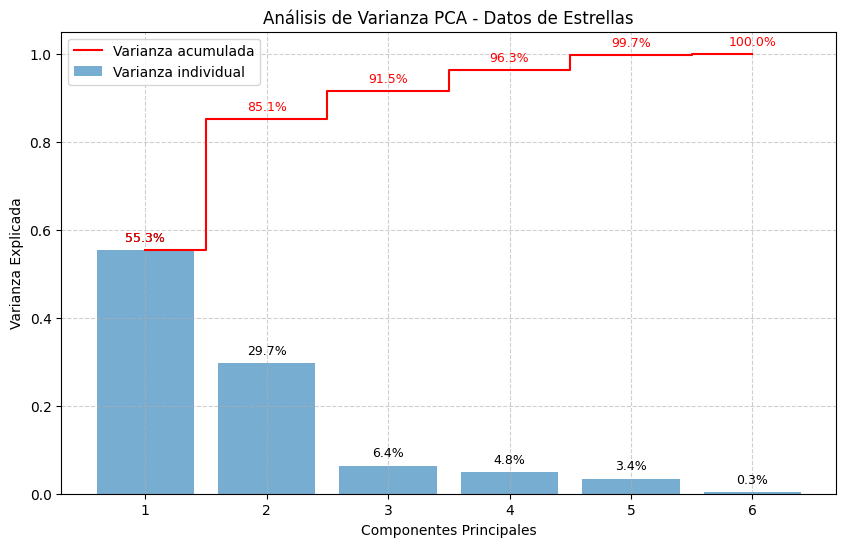

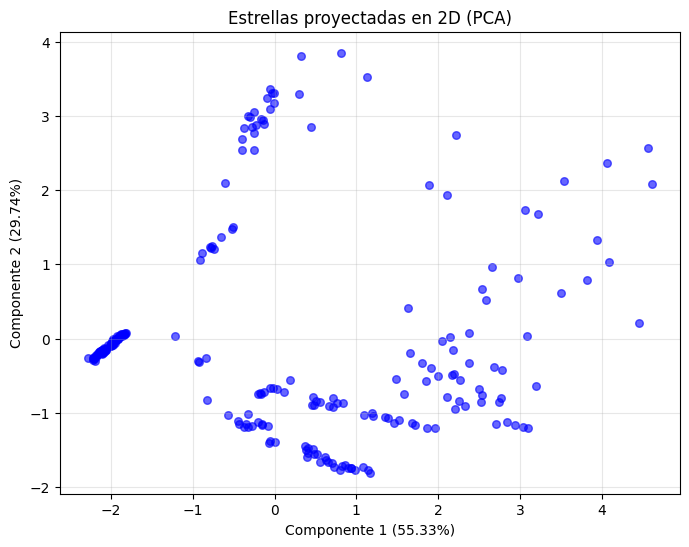

In [5]:
from sklearn.pipeline import Pipeline

# Preparamos los datos (X)
# Usamos las variables originales + las que hemos mapeado a números
features = ['Temperature', 'L', 'R', 'A_M', 'Rango_Color', 'Rango_Espectral']
X = df[features]

# Creamos el Pipeline 
# Paso 1: Escalar, Paso 2: PCA (sin número de componentes para ver todas primero)
pipeline_exploratorio = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA())
])

# Ajustamos y transformamos
X_pca_full = pipeline_exploratorio.fit_transform(X)
pca_step = pipeline_exploratorio.named_steps['pca']

# Visualizamos la varianza
varianza_explicada = pca_step.explained_variance_ratio_
varianza_acumulada = np.cumsum(varianza_explicada)

plt.figure(figsize=(10, 6))
plt.bar(range(1, len(varianza_explicada) + 1), varianza_explicada, alpha=0.6, label='Varianza individual')
plt.step(range(1, len(varianza_acumulada) + 1), varianza_acumulada, where='mid', label='Varianza acumulada', color='red')

# Añadimos etiquetas de porcentaje y hacemos que se interprete mejor visualmente
for i, (ev, cv) in enumerate(zip(varianza_explicada, varianza_acumulada)):
    plt.text(i + 1, ev + 0.02, f"{ev:.1%}", ha='center', fontsize=9)
    plt.text(i + 1, cv + 0.02, f"{cv:.1%}", ha='center', color='red', fontsize=9)

plt.xlabel('Componentes Principales')
plt.ylabel('Varianza Explicada')
plt.title('Análisis de Varianza PCA - Datos de Estrellas')
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Ahora aplicamos la reducción a 2 componentes
pipeline_final = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=2, random_state=100522245)) # Semilla de NIA
])

X_reduced = pipeline_final.fit_transform(X)

# Guardamos el resultado en un DataFrame para el clustering posterior
df_pca_estrellas = pd.DataFrame(data=X_reduced, columns=['PC1', 'PC2'])

# Visualización final en 2D
plt.figure(figsize=(8, 6))
plt.scatter(df_pca_estrellas['PC1'], df_pca_estrellas['PC2'], alpha=0.6, c='blue', s=30)
plt.title('Estrellas proyectadas en 2D (PCA)')
plt.xlabel(f'Componente 1 ({varianza_explicada[0]:.2%})')
plt.ylabel(f'Componente 2 ({varianza_explicada[1]:.2%})')
plt.grid(True, alpha=0.3)
plt.show()

Para desarrollar **PCA**, primero creamos la matriz de datos **X**, que únicamente contiene las variables que vamos a usar en el modelo (ya que **Color** y **Spectral_Class** no las usamos al no ser numéricas). A continuación, construimos un **Pipeline** que primero escala con **StandardScaler** y después hacemos **PCA** sin especificar el número de componentes con el objetivo de observar cómo de importante es cada componente para explicar los datos (aunque se nos dice que debemos reducir a 2 dimensiones, creemos que es buena práctica observarlo primero). Después, entrenamos el pipeline y transformamos los datos y accedemos a **PCA**. Ahora, tomando ese objeto **PCA**, calculamos la **varianza explicada**, para ver cuánta información captura cada componente, y la **varianza acumulada**, para ver cuánta información va capturada en total. Una vez hecho esto, hacemos un gráfico para reconocer ese ***elbow*** que nos ayuda a decidir en que momento podemos dejar de añadir componentes porque no ayuda mucho. Como se puede observar en dicho gráfico, la **primera componente captura el 55,3%** y la **segunda componente el 29,7%**, elevando la **captura total al 85,1%**. La **tercera componente solo captura el 6,4%**, por lo que no creemos necesario incluirla, razón por la cual nuestro **PCA será de 2 dimensiones**, como dice el enunciado. Ahora ya podemos aplicar la **reducción a 2 componentes** en **PCA** (haciendo antes **StandardScaler** obviamente). Finalmente, guardamos el resultado (**PC1 y PC2**) en un nuevo **Dataframe** con el objetivo de usarlo posteriormente en clustering y, además, observamos esa transformación en 2 dimensiones con el objetivo de comprobar si se forman grupos (y efectivamente, observamos que sí, habiendo un grupo más a la izquierda, otro más abajo, otro arriba...). 

A continuación procederemos a aplicar los diferentes **algoritmos de clustering**:

## **APARTADO 3: ALGORITMOS DE CLUSTERING**

#### **APARTADO 3.1: AJUSTE HIPERPARÁMETROS K-MEANS**

Comenzaramos este apartado llevando a cabo **K-Means**. En primer lugar, debemos decir el número **K** de clusters que queremos que haya. Para ello, implementamos el **Método del Codo** y el **Método Silhouette** con el objetivo de estar totalmente seguros del número de clusters que usaremos, pues veremos el número obtenido con ambos métodos:

In [6]:
from sklearn.metrics import silhouette_score

# Usamos los datos del PCA
X_input = X_reduced

# Establecemos el rango de K a evaluar
range_n_clusters = range(2, 11)
inertias = []
silhouette_vals = []

# Entrenamos un modelo K-Means para cada número de clusters
for n_clusters in range_n_clusters:
    modelo_kmeans = KMeans(
        n_clusters=n_clusters,
        n_init=20,
        random_state=100522245
    )

    # Aprende centroides y asigna etiquetas
    labels_kmeans = modelo_kmeans.fit_predict(X_input)

    # Guardamos métricas
    inertias.append(modelo_kmeans.inertia_)
    silhouette_vals.append(silhouette_score(X_input, labels_kmeans))

# Mejor K según Silhouette
best_k_sil_kmeans = range_n_clusters[np.argmax(silhouette_vals)]
print(f"Mejor K según Silhouette (K-Means): {best_k_sil_kmeans}")

Mejor K según Silhouette (K-Means): 6


Para seleccionar el mejor número de clusters en **K-Means**, evaluamos dos criterios complementarios para cada valor de $K$ entre 2 y 10. El **Método del Codo** usa la inercia (suma de distancias internas al centroide): cuanto menor, mejor compactación, aunque llega un punto donde la mejora deja de ser significativa. El **Método Silhouette** mide cohesión y separación simultáneamente: valores más altos indican clusters mejor definidos. En la siguiente celda visualizamos ambas curvas para tomar la decisión final de $K$.

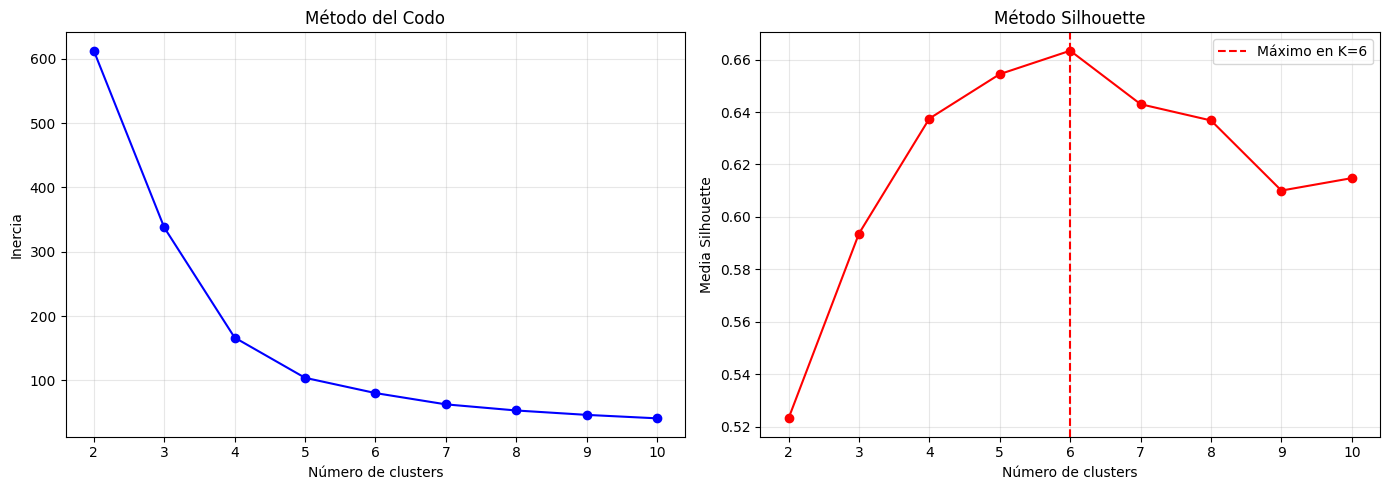

In [7]:
# Visualización de criterios para elegir K
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico del Codo
ax1.plot(range_n_clusters, inertias, marker='o', color='blue')
ax1.set_title("Método del Codo")
ax1.set_xlabel('Número de clusters')
ax1.set_ylabel('Inercia')
ax1.grid(alpha=0.3)

# Gráfico de Silhouette
ax2.plot(range_n_clusters, silhouette_vals, marker='o', color='red')
ax2.axvline(best_k_sil_kmeans, color='r', linestyle='--', label=f"Máximo en K={best_k_sil_kmeans}")
ax2.set_title("Método Silhouette")
ax2.set_xlabel('Número de clusters')
ax2.set_ylabel('Media Silhouette')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

A partir de las gráficas, el **Método del Codo** muestra una zona de inflexión razonable en torno a $K=4$, $K=5$ y $K=6$, por lo que no ofrece una única elección clara. Sin embargo, el **Método Silhouette** alcanza su valor máximo en $K=6$, indicando la mejor combinación de cohesión interna y separación entre grupos. Por ello, fijamos **$K=6$** para K-Means. 

Ahora pasamos a **Hierarchical Clustering** para elegir el mejor tipo de *linkage* y el número de clusters.

#### **APARTADO 3.2: AJUSTE HIPERPARÁMETROS HIERARCHICAL CLUSTERING**

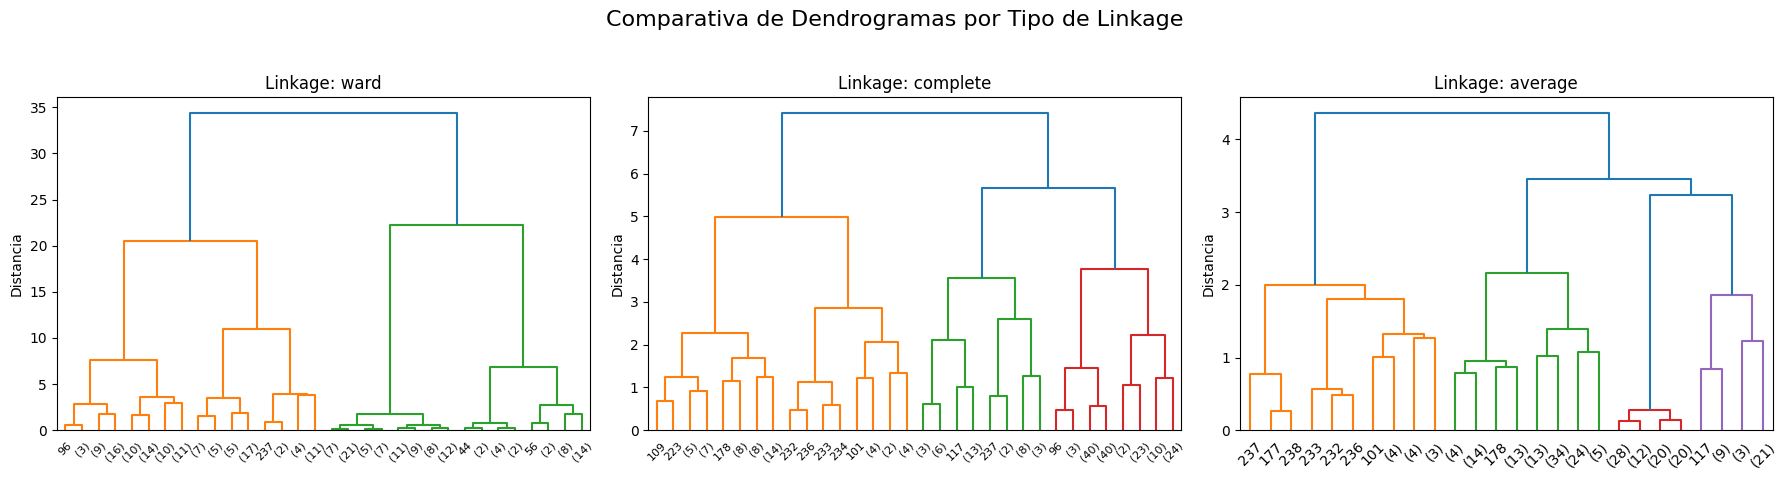

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch

# Usamos los datos del PCA
X_input = X_reduced

# Comparativa visual de linkages
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

for i, link in enumerate(['ward', 'complete', 'average']):
    Z_temp = sch.linkage(X_input, method=link)
    sch.dendrogram(Z_temp, ax=axs[i], truncate_mode='level', p=4)
    axs[i].set_title(f"Linkage: {link}")
    axs[i].set_ylabel("Distancia")

plt.suptitle("Comparativa de Dendrogramas por Tipo de Linkage", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Tras comparar los dendrogramas, seleccionamos **Ward** como método de *linkage*. Visualmente ofrece una estructura más clara y equilibrada, con separaciones más definidas entre grupos. Además, **Ward** minimiza la varianza interna en cada cluster, lo que favorece grupos más compactos y homogéneos.

--- RESULTADOS MATEMÁTICOS (WARD) ---
Mayor salto detectado en el índice de fusión: 237
Número óptimo de clusters según salto de altura: 2


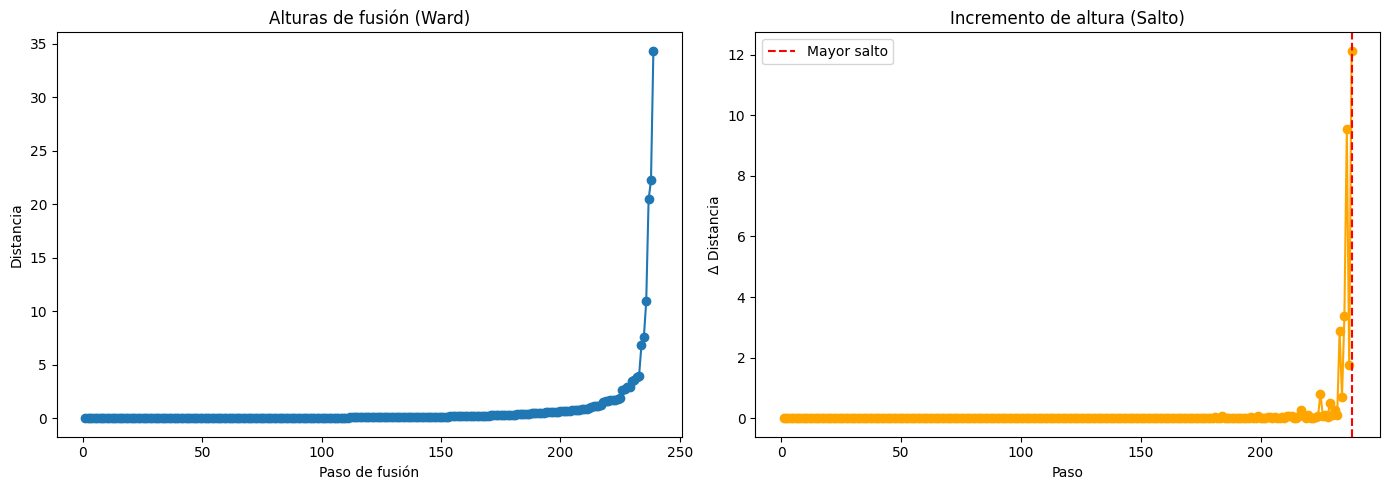

Mejor K según Silhouette (Ward): 7


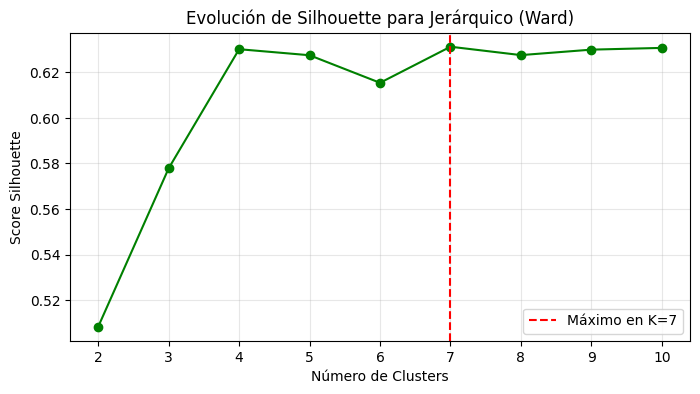

In [9]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

# ===============================
# 1) Método del salto de altura
# ===============================
Z = sch.linkage(X_input, method='ward')
heights = Z[:, 2]
diffs = np.diff(heights)
idx_max_jump = np.argmax(diffs)

# Estimación matemática del número de clusters
n_clusters_h_mat = len(heights) - idx_max_jump

print("--- RESULTADOS MATEMÁTICOS (WARD) ---")
print(f"Mayor salto detectado en el índice de fusión: {idx_max_jump}")
print(f"Número óptimo de clusters según salto de altura: {n_clusters_h_mat}")

# Gráficas del salto
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(range(1, len(heights) + 1), heights, marker='o')
ax[0].set_title("Alturas de fusión (Ward)")
ax[0].set_xlabel("Paso de fusión")
ax[0].set_ylabel("Distancia")

ax[1].plot(range(1, len(diffs) + 1), diffs, marker='o', color='orange')
ax[1].axvline(x=idx_max_jump + 1, color='r', linestyle='--', label='Mayor salto')
ax[1].set_title("Incremento de altura (Salto)")
ax[1].set_xlabel("Paso")
ax[1].set_ylabel("Δ Distancia")
ax[1].legend()

plt.tight_layout()
plt.show()

# ===============================
# 2) Método Silhouette (K=2..10)
# ===============================
range_n_clusters = range(2, 11)
sil_scores = []

for n in range_n_clusters:
    model = AgglomerativeClustering(n_clusters=n, linkage='ward')
    labels_hclust = model.fit_predict(X_input)
    sil_scores.append(silhouette_score(X_input, labels_hclust))

best_k_sil = range_n_clusters[np.argmax(sil_scores)]
print(f"Mejor K según Silhouette (Ward): {best_k_sil}")

plt.figure(figsize=(8, 4))
plt.plot(range_n_clusters, sil_scores, marker='o', color='green')
plt.title("Evolución de Silhouette para Jerárquico (Ward)")
plt.xlabel("Número de Clusters")
plt.ylabel("Score Silhouette")
plt.axvline(x=best_k_sil, color='r', linestyle='--', label=f"Máximo en K={best_k_sil}")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

La parte matemática del salto de altura sugiere **K=2**, lo que describe bien la separación global de los datos. Sin embargo, el análisis de **Silhouette** muestra una cohesión alta en **K=6**, indicando subestructuras internas relevantes. Dado que el objetivo es clasificar estrellas con criterio astronómico, elegimos **K=6** para capturar mejor esas diferencias finas entre tipos estelares.

#### **APARTADO 3.3: AJUSTE HIPERPARÁMETROS DBSCAN**

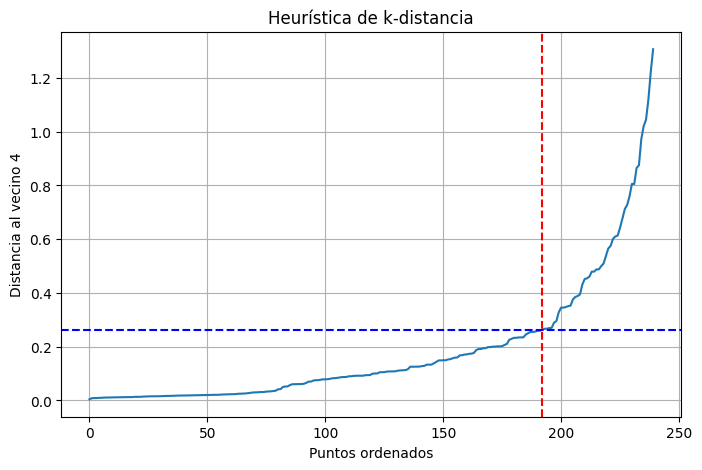

eps sugerido ≈ 0.263


In [10]:
from sklearn.neighbors import NearestNeighbors

# Definimos un min_samples inicial (regla general: 2 * dimensiones = 4)
min_samples_heur = 4

# Calculamos las distancias al vecino k-ésimo
nn = NearestNeighbors(n_neighbors=min_samples_heur)
nn.fit(X_reduced)
distances, indices = nn.kneighbors(X_reduced)

# Graficamos
sorted_distances = np.sort(distances[:, min_samples_heur-1], axis=0)

# Elegimos un punto cerca del 80% (heurística común)
x_point = int(len(sorted_distances) * 0.8)
y_value = sorted_distances[x_point]

plt.figure(figsize=(8, 5))
plt.plot(sorted_distances)
plt.title("Heurística de k-distancia")
plt.xlabel("Puntos ordenados")
plt.ylabel(f"Distancia al vecino {min_samples_heur}")

# Marcar codo aproximado
plt.axvline(x=x_point, color='r', linestyle='--')
plt.axhline(y=y_value, color='b', linestyle='--')

plt.grid(True)
plt.show()

print(f"eps sugerido ≈ {y_value:.3f}")

Se observa que **el codo se encuentra en un rango entre 0.20 y 0.40, recomendándose eps=0.263**. Este rango se tomará como punto de partida para el ajuste fino de hiperparámetros mediante la métrica DBCV:

In [11]:
# Instalar métrica específica para DBSCAN (dbcv)
!pip install "git+https://github.com/FelSiq/DBCV"

import dbcv

# Definimos rangos basados en lo que vimos en la gráfica anterior
# Observamos que el codo está entre 0.20 y 0.40, por lo que probamos valores en ese rango
eps_values = [0.20, 0.21, 0.22, 0.23, 0.24, 0.25, 0.263, 0.27, 0.28, 0.29, 0.30, 0.31, 0.32, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.40]
min_samples_values = [3, 4, 5, 6]

print(f"{'MS':<3} | {'EPS':<4} | {'Clusters':<8} | {'% Ruido':<8} | {'DBCV Score'}")
print("-" * 50)

best_dbcv = -1
best_params = {}

for ms in min_samples_values:
    for eps in eps_values:
        db = DBSCAN(eps=eps, min_samples=ms).fit(X_reduced)
        labels_dbscan = db.labels_
        n_clusters = len(set(labels_dbscan) - {-1})
        
        if n_clusters > 1:
            # Importante: DBCV mide densidad, el valor más alto es el mejor
            score = dbcv.dbcv(X_reduced, labels_dbscan)
            n_noise = list(labels_dbscan).count(-1)
            perc_noise = (n_noise / len(labels_dbscan)) * 100
            
            print(f"{ms:<3} | {eps:<4.2f} | {n_clusters:<8} | {perc_noise:>7.1f}% | {score:.4f}")
            
            if score > best_dbcv:
                best_dbcv = score
                best_params = {'eps': eps, 'min_samples': ms, 'labels': labels_dbscan}

print(f"\nMEJOR CONFIGURACIÓN: {best_params['eps']} eps, {best_params['min_samples']} ms (DBCV: {best_dbcv:.4f})")

  Cloning https://github.com/FelSiq/DBCV to /tmp/pip-req-build-jfb0afey
  Running command git clone --filter=blob:none --quiet https://github.com/FelSiq/DBCV /tmp/pip-req-build-jfb0afey
  Resolved https://github.com/FelSiq/DBCV to commit 13c3896ef78d12f1e3e1cbd394f2db9a09637ffd
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
MS  | EPS  | Clusters | % Ruido  | DBCV Score
--------------------------------------------------
3   | 0.20 | 14       |    15.8% | 0.7899
3   | 0.21 | 13       |    15.4% | 0.7829
3   | 0.22 | 13       |    15.4% | 0.7829
3   | 0.23 | 13       |    14.2% | 0.7736
3   | 0.24 | 13       |    13.8% | 0.7764
3   | 0.25 | 13       |    13.8% | 0.7764
3   | 0.26 | 13       |    13.8% | 0.7764
3   | 0.27 | 11       |    13.8% | 0.6890
3   | 0.28 | 11       |    13.8% | 0.6890
3   | 0.29 | 10       |    13.8% | 0.7295
3   | 0.30 | 8        |    13.3% | 0.6567
3   | 0.31 | 8        |    

**El ajuste de los hiperparámetros de DBSCAN la realizamos en dos fases**: una **estimación inicial basada en la heurística del gráfico k-distance** y una **optimización posterior mediante la métrica DBCV**. En primer lugar, se utiliza la **heurística del gráfico de k-distance** para obtener una estimación inicial del parámetro ***eps***. Este método consiste en calcular la distancia al vecino k-ésimo para cada punto, ordenarlas de menor a mayor y analizar el punto de inflexión de la curva (codo), que indica un cambio en la densidad de los datos. Se ha fijado ***min_samples = 4*** como valor inicial, siguiendo la regla general de **utilizar aproximadamente el doble de la dimensionalidad del espacio de datos**. A partir del análisis visual de la curva, se observa que el codo se encuentra aproximadamente en el **rango [0.20, 0.40]**, obteniéndose un valor representativo de ***eps ≈ 0.263***. Este valor no se toma como solución definitiva, sino como una guía para acotar el espacio de búsqueda de hiperparámetros. A partir del rango identificado en la fase anterior, se realiza una búsqueda exhaustiva de combinaciones de ***eps*** y ***min_samples*** con el objetivo de optimizar la calidad de los clusters. Se evalúan los siguientes rangos: ***eps[0.20, 0.40]*** y ***min_samples ∈ [3, 4, 5, 6]***. Para cada combinación, se ajusta un modelo **DBSCAN** y se evalúa su calidad mediante la métrica **DBCV**. Tras evaluar todas las combinaciones, el mejor resultado se obtiene con: ***eps = 0.37, min_samples = 4 y DBCV = 0.8309***.

Una vez ajustados los hiperparámetros de cada método, procedemos a **comparar los tres algoritmos de clustering:**

#### **APARTADO 3.4: COMPARACIÓN DE ALGORITMOS DE CLUSTERING**

Una vez obtenidos los hiperparámetros óptimos para cada uno de los modelos en los pasos anteriores, procedemos a realizar una comparación visual y cuantitativa de los tres algoritmos: **K-Means** (K=6), **Hierarchical Clustering** (Linkage Ward, K=6) y **DBSCAN** (eps=0.37, min_samples=4).

Para ello, entrenaremos cada modelo utilizando los datos reducidos a 2 dimensiones mediante PCA y representaremos los resultados de sus agrupaciones en gráficos de dispersión. Además, extraeremos sus métricas de evaluación correspondientes (Silhouette Score para los modelos particionales/jerárquicos y DBCV para DBSCAN) con el objetivo de analizar qué algoritmo consigue clasificar de forma más lógica los distintos tipos de estrellas.

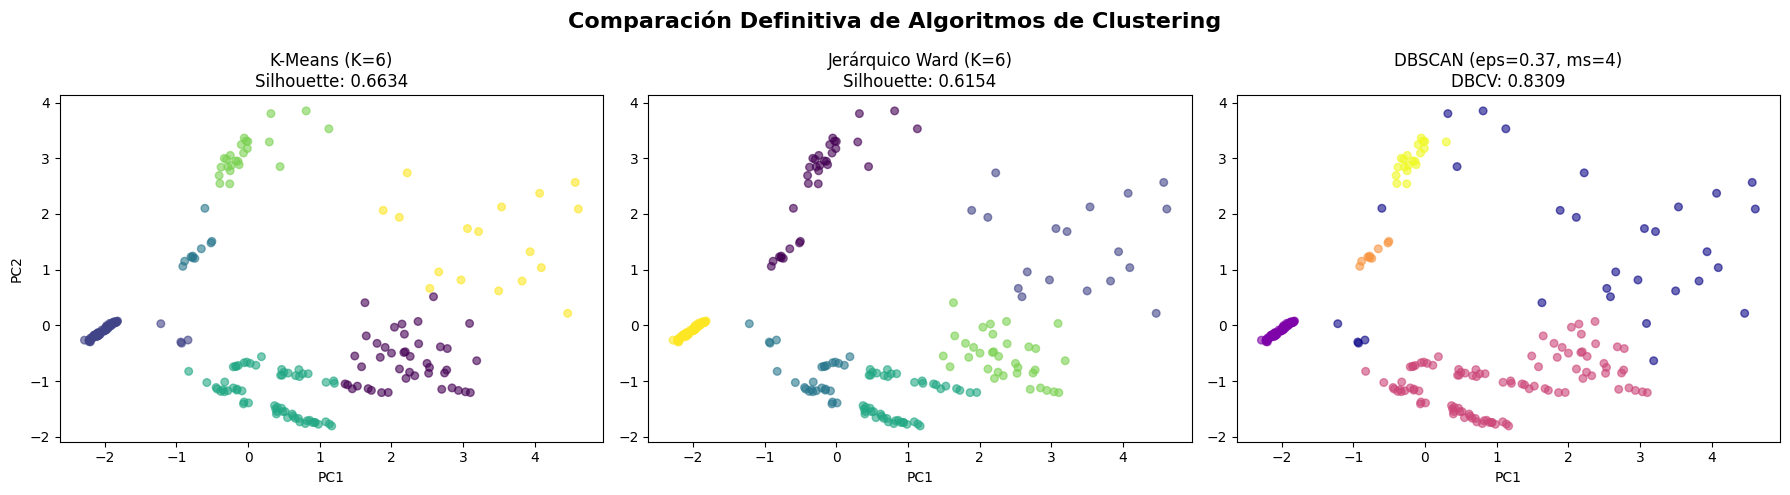

In [12]:
import dbcv

# 1. Preparamos un lienzo para 3 gráficos en fila (CORREGIDO: subplots)
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# Modelo 1: K-MEANS (K=6)
kmeans = KMeans(n_clusters=6, n_init=20, random_state=100522245)
labels_kmeans = kmeans.fit_predict(X_reduced)
sil_kmeans = silhouette_score(X_reduced, labels_kmeans)

# Pintamos K-Means
axs[0].scatter(X_reduced[:, 0], X_reduced[:, 1], c=labels_kmeans, cmap='viridis', alpha=0.6, s=30)
axs[0].set_title(f"K-Means (K=6)\nSilhouette: {sil_kmeans:.4f}")
axs[0].set_xlabel("PC1")
axs[0].set_ylabel("PC2")

# Modelo 2: HIERARCHICAL CLUSTERING (Ward, K=6)
hc = AgglomerativeClustering(n_clusters=6, linkage='ward')
labels_hc = hc.fit_predict(X_reduced)
sil_hc = silhouette_score(X_reduced, labels_hc)

# Pintamos Jerárquico
axs[1].scatter(X_reduced[:, 0], X_reduced[:, 1], c=labels_hc, cmap='viridis', alpha=0.6, s=30)
axs[1].set_title(f"Jerárquico Ward (K=6)\nSilhouette: {sil_hc:.4f}")
axs[1].set_xlabel("PC1")

# Modelo 3: DBSCAN (eps=0.37, min_samples=4)
dbscan = DBSCAN(eps=0.37, min_samples=4)
labels_dbscan = dbscan.fit_predict(X_reduced)

# Reutilizamos la librería dbcv instalada en el paso anterior (CORREGIDO: nombre de la variable)
dbcv_score = dbcv.dbcv(X_reduced, labels_dbscan)

# Pintamos DBSCAN
axs[2].scatter(X_reduced[:, 0], X_reduced[:, 1], c=labels_dbscan, cmap='plasma', alpha=0.6, s=30)
axs[2].set_title(f"DBSCAN (eps=0.37, ms=4)\nDBCV: {dbcv_score:.4f}")
axs[2].set_xlabel("PC1")

# Mostramos todo junto
plt.suptitle("Comparación Definitiva de Algoritmos de Clustering", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### **Análisis de Resultados y Comparación de Modelos**

Tras ejecutar los tres algoritmos de clustering con sus hiperparámetros óptimos sobre los datos reducidos (PCA), hemos obtenido una visión clara de cómo cada uno agrupa las estrellas en el espacio bidimensional.

#### **1. Evaluación Cuantitativa (Métricas)**
* **K-Means (K=6):** Ha obtenido un *Silhouette Score* de **0.6634**.
* **Clustering Jerárquico (Ward, K=6):** Ha obtenido un *Silhouette Score* de **0.6154**.
* **DBSCAN (eps=0.37, ms=4):** Ha obtenido un *DBCV Score* de **0.8309**.

#### **2. Evaluación Cualitativa (Discusión)**
* **K-Means vs. Jerárquico:** Ambos modelos muestran una estructura de agrupación muy similar. Dividen el conjunto de datos en 6 familias estelares bien diferenciadas y compactas. Sin embargo, **K-Means** presenta una cohesión ligeramente superior según la métrica Silhouette, lo que indica que las fronteras entre sus clústeres están mejor definidas.
* **DBSCAN:** Aunque este modelo presenta la métrica más alta (DBCV de 0.8309), su naturaleza basada en densidad no es la más adecuada para este problema específico. Como se observa en la gráfica, DBSCAN etiqueta varios puntos periféricos como **ruido (outliers)**. En el contexto de esta práctica, el objetivo es clasificar **todas** las estrellas en categorías astronómicas (Enanas, Gigantes, etc.) basándonos en sus atributos físicos. Dejar estrellas sin clasificar ("puntos de ruido") restaría utilidad al modelo para un análisis astronómico completo.

#### **3. Conclusión del Ganador**
Considerando tanto la limpieza visual como las métricas y la necesidad de asignar una categoría a cada elemento de la muestra, **K-Means (K=6)** se consolida como el algoritmo más eficiente y equilibrado para este conjunto de datos.